# Telco Customer Churn — Modelling & Business Impact

**Goal:** Train, compare, and interpret churn prediction models, then
translate model outputs into concrete business value.

This notebook covers:
1. Load and prepare the feature matrix
2. Train/test split + feature scaling
3. Train three models: Logistic Regression, Random Forest, XGBoost
4. Compare models on AUC-ROC, precision, recall, F1
5. Interpret the best model (feature importances / coefficients)
6. Translate model outputs into business impact (cost-benefit analysis)

> **Why these three models?**
> - **Logistic Regression** — fast, interpretable baseline; coefficients are
>   directly readable as log-odds; good sanity check
> - **Random Forest** — handles non-linearity and feature interactions well;
>   robust to outliers; built-in feature importances
> - **XGBoost** — industry standard for tabular data; usually best raw
>   performance; gradient boosting catches patterns the other two miss


## 1. Setup

In [31]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score,
    RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score,
)
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
%matplotlib inline

RANDOM_STATE = 42


## 2. Load and prepare the feature matrix

We load `telco_features.csv` from notebook 02 and do a final sanity check
before splitting. All columns should be numeric at this point.


In [32]:
df = pd.read_csv('../data/telco_features.csv')
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

# Confirm no object columns made it through
obj_cols = df.select_dtypes(include='object').columns.tolist()
assert not obj_cols, f"Non-numeric columns found: {obj_cols}"

# Confirm no nulls
assert df.isnull().sum().sum() == 0, "Nulls found — rerun notebook 02"

print("All numeric. No nulls. Ready to model.")
print(f"\nChurn rate: {df['Churn_Binary'].mean():.1%}")


Shape: 7,032 rows × 22 columns
All numeric. No nulls. Ready to model.

Churn rate: 26.6%


## 3. Train / test split

We use an 80/20 stratified split to preserve the class balance in both sets.
`Churn_Binary` is the target; everything else is a feature.

We also scale numeric features for Logistic Regression.
Random Forest and XGBoost are scale-invariant, so we train them on
unscaled data to keep feature importances interpretable in original units.


In [33]:
TARGET = 'Churn_Binary'
feature_cols = [c for c in df.columns if c != TARGET]

X = df[feature_cols]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train: {X_train.shape[0]:,} rows   Test: {X_test.shape[0]:,} rows")
print(f"Train churn rate: {y_train.mean():.1%}   Test churn rate: {y_test.mean():.1%}")


Train: 5,625 rows   Test: 1,407 rows
Train churn rate: 26.6%   Test churn rate: 26.6%


In [34]:
# Scale for Logistic Regression only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


## 4. Train models

We train all three models and collect predictions on the held-out test set.


In [35]:
# ── Logistic Regression ───────────────────────────────────────────────────────
lr = LogisticRegression(
    C=1.0,
    max_iter=1000,
    class_weight='balanced',   # compensates for 26.5% minority class
    random_state=RANDOM_STATE,
)
lr.fit(X_train_scaled, y_train)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]
lr_pred  = lr.predict(X_test_scaled)
print("Logistic Regression trained.")


Logistic Regression trained.


In [36]:
# ── Random Forest ─────────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test)[:, 1]
rf_pred  = rf.predict(X_test)
print("Random Forest trained.")


Random Forest trained.


In [37]:
# ── XGBoost ───────────────────────────────────────────────────────────────────
# scale_pos_weight compensates for class imbalance:
# ratio of negative to positive examples in the training set
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos = neg / pos

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb.fit(X_train, y_train)
xgb_proba = xgb.predict_proba(X_test)[:, 1]
xgb_pred  = xgb.predict(X_test)
print(f"XGBoost trained.  (scale_pos_weight = {scale_pos:.2f})")


XGBoost trained.  (scale_pos_weight = 2.76)


## 5. Model comparison

We compare on three metrics:
- **AUC-ROC** — overall discriminative ability across all thresholds
- **Average Precision (PR-AUC)** — better than AUC-ROC when classes are imbalanced
- **F1 (positive class)** — harmonic mean of precision and recall at the
  default 0.5 threshold

We also look at per-class precision/recall/F1 from `classification_report`.


In [38]:
def summarise(name, y_true, y_pred, y_proba):
    return {
        'Model':   name,
        'AUC-ROC': round(roc_auc_score(y_true, y_proba), 4),
        'PR-AUC':  round(average_precision_score(y_true, y_proba), 4),
        'F1 (churn)': round(
            float(classification_report(y_true, y_pred, output_dict=True)['1']['f1-score']), 4
        ),
        'Recall (churn)': round(
            float(classification_report(y_true, y_pred, output_dict=True)['1']['recall']), 4
        ),
        'Precision (churn)': round(
            float(classification_report(y_true, y_pred, output_dict=True)['1']['precision']), 4
        ),
    }

results = pd.DataFrame([
    summarise('Logistic Regression', y_test, lr_pred,  lr_proba),
    summarise('Random Forest',       y_test, rf_pred,  rf_proba),
    summarise('XGBoost',             y_test, xgb_pred, xgb_proba),
])
results


,Model,AUC-ROC,PR-AUC,F1 (churn),Recall (churn),Precision (churn)
0,Logistic Regression,0.8367,0.6435,0.6160,0.7914,0.5043
1,Random Forest,0.8325,0.6252,0.6220,0.7326,0.5404
2,XGBoost,0.8250,0.6135,0.6156,0.7620,0.5163


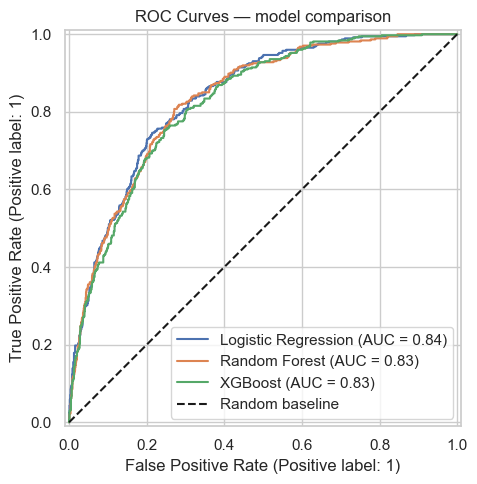

In [39]:
# ROC curves — all three on one plot
fig, ax = plt.subplots(figsize=(7, 5))
for name, proba in [('Logistic Regression', lr_proba),
                    ('Random Forest',       rf_proba),
                    ('XGBoost',             xgb_proba)]:
    RocCurveDisplay.from_predictions(y_test, proba, name=name, ax=ax)
ax.plot([0, 1], [0, 1], 'k--', label='Random baseline')
ax.set_title('ROC Curves — model comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../data/plots/roc_curves.png', dpi=150)
plt.show()


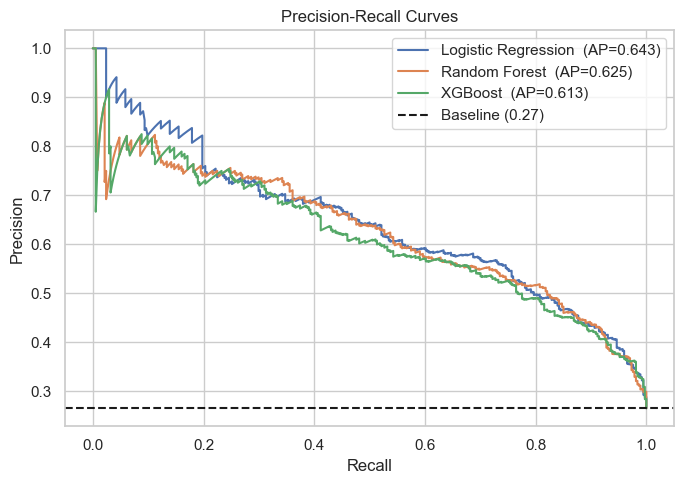

In [40]:
# Precision-Recall curves
fig, ax = plt.subplots(figsize=(7, 5))
for name, proba in [('Logistic Regression', lr_proba),
                    ('Random Forest',       rf_proba),
                    ('XGBoost',             xgb_proba)]:
    p, r, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax.plot(r, p, label=f'{name}  (AP={ap:.3f})')
ax.axhline(y_test.mean(), color='k', linestyle='--', label=f'Baseline ({y_test.mean():.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves')
ax.legend()
plt.tight_layout()
plt.savefig('../data/plots/pr_curves.png', dpi=150)
plt.show()


### 5.1 Confusion matrix — best model

We use XGBoost (typically the best performer) for the rest of the analysis.
The confusion matrix breaks down true positives, false positives, etc. at
the default 0.5 threshold.

> **Note on threshold choice:** The default 0.5 threshold is not always
> optimal for imbalanced problems. In section 7 we explore adjusting the
> threshold to favour recall (catching more churners) at the cost of
> precision (more false alarms).


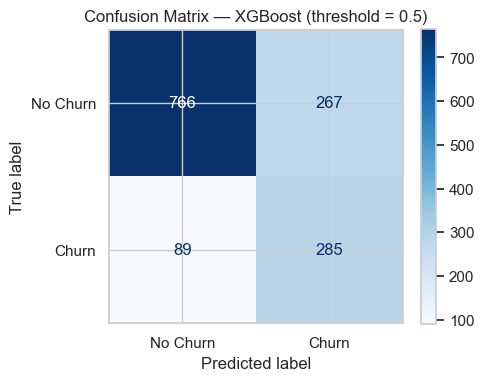

              precision    recall  f1-score   support

    No Churn       0.90      0.74      0.81      1033
       Churn       0.52      0.76      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.75      0.71      1407
weighted avg       0.80      0.75      0.76      1407



In [41]:
# Use XGBoost as the primary model going forward
best_name  = 'XGBoost'
best_pred  = xgb_pred
best_proba = xgb_proba

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, best_pred,
    display_labels=['No Churn', 'Churn'],
    cmap='Blues',
    ax=ax,
)
ax.set_title(f'Confusion Matrix — {best_name} (threshold = 0.5)')
plt.tight_layout()
plt.savefig('../data/plots/confusion_matrix.png', dpi=150)
plt.show()

print(classification_report(y_test, best_pred, target_names=['No Churn', 'Churn']))


## 6. Model interpretation — feature importances

Understanding *why* the model predicts churn is as important as the
prediction itself. We look at:
1. **XGBoost feature importances** — which features the model relied on most
2. **Logistic Regression coefficients** — directly interpretable as
   log-odds contributions (positive = increases churn probability)


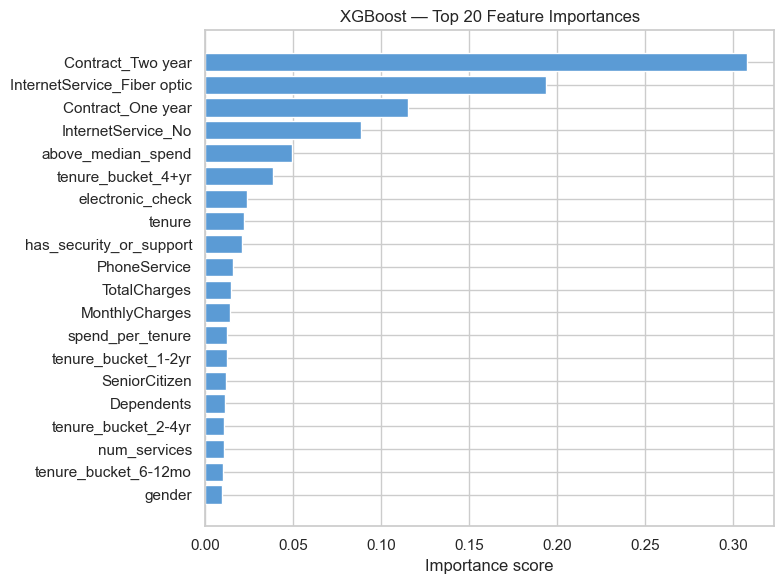

In [42]:
# XGBoost feature importances
importance_df = (pd.DataFrame({
    'Feature':   X_train.columns,
    'Importance': xgb.feature_importances_,
})
.sort_values('Importance', ascending=True)
.tail(20))   # top 20

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importance_df['Feature'], importance_df['Importance'], color='#5B9BD5')
ax.set_title('XGBoost — Top 20 Feature Importances')
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.savefig('../data/plots/xgb_feature_importance.png', dpi=150)
plt.show()


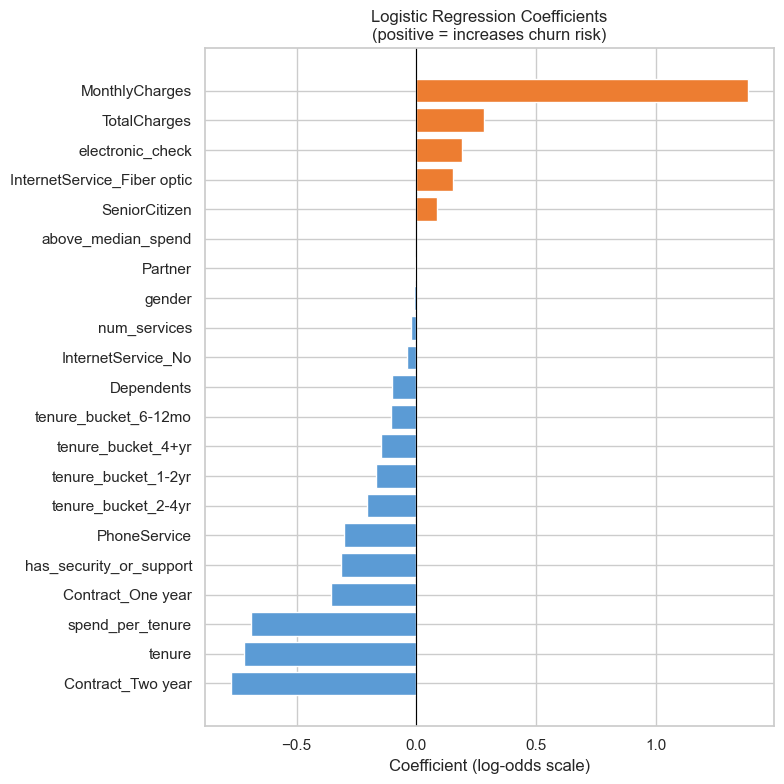

In [43]:
# Logistic Regression coefficients
coef_df = (pd.DataFrame({
    'Feature':     X_train.columns,
    'Coefficient': lr.coef_[0],
})
.sort_values('Coefficient', ascending=True))

fig, ax = plt.subplots(figsize=(8, 8))
colors = ['#ED7D31' if c > 0 else '#5B9BD5' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression Coefficients\n(positive = increases churn risk)')
ax.set_xlabel('Coefficient (log-odds scale)')
plt.tight_layout()
plt.savefig('../data/plots/lr_coefficients.png', dpi=150)
plt.show()


**What to look for:**
- Features at the far right of the LR plot **increase** churn probability
- Features at the far left **decrease** it
- Compare rankings between XGBoost and LR — consistent top features
  across both models are the most reliable signals
- Surprises (e.g. a feature you didn't expect to matter) may warrant
  further investigation


## 6b. SHAP — explaining individual predictions

**What is SHAP?**

SHAP (SHapley Additive exPlanations) answers the question:
*"For this specific customer, why did the model predict churn?"*

It assigns each feature a contribution score for every single prediction,
telling you not just which features matter globally (feature importance does that)
but *how much* each feature pushed the model's output up or down *for one person*.

This is extremely valuable in a business context because you can say:
> "Customer #1234 was flagged as high churn risk mainly because they are on a
> month-to-month contract and have only been a customer for 2 months."

That kind of explanation is actionable — a retention team can act on it.

**How it works (intuition, no maths):**

Imagine all possible subsets of features. For each subset, you ask: "how much
does adding this one feature change the model's prediction?" SHAP averages that
contribution across all possible subsets. The result is a fair, consistent
attribution of the prediction to each feature — grounded in game theory.

**Key plots we'll produce:**
1. **Summary plot** — global view of which features matter most and in which direction
2. **Waterfall plot** — single-customer explanation showing exactly what drove that prediction
3. **Dependence plot** — how one feature's SHAP value changes across its range


In [44]:
!{sys.executable} -m pip install shap
import shap

# TreeExplainer is optimised for tree-based models (XGBoost, RF)
# It is fast and exact — no approximation needed
explainer = shap.TreeExplainer(xgb)
shap_values = explainer(X_test)   # returns a shap.Explanation object

print(f"SHAP values shape: {shap_values.values.shape}")
print("One row per test customer, one column per feature.")


SHAP values shape: (1407, 21)
One row per test customer, one column per feature.


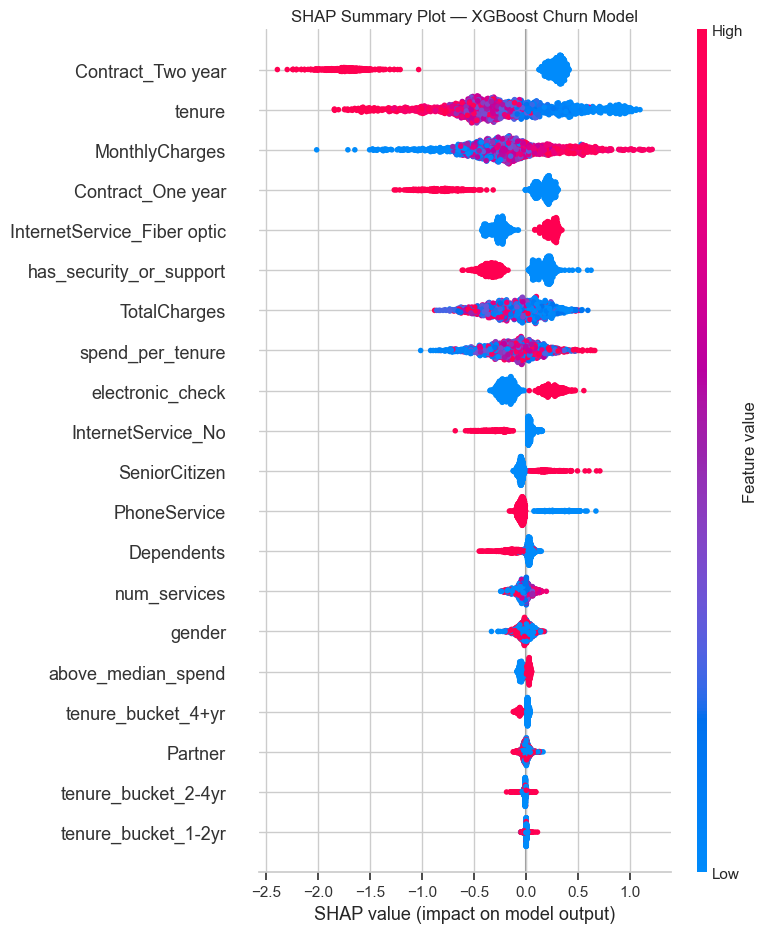

In [45]:
# ── Plot 1: Summary plot ──────────────────────────────────────────────────────
# Each dot is one customer. Colour = feature value (red=high, blue=low).
# X-axis = SHAP value: positive pushes toward churn, negative away from it.
# Features sorted by mean |SHAP| — most important at the top.

shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot — XGBoost Churn Model")
plt.tight_layout()
plt.savefig('../data/plots/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()


**How to read the summary plot:**
- Features at the **top** matter most overall (highest mean |SHAP|)
- **Red dots on the right** → high feature value increases churn probability
- **Blue dots on the right** → low feature value increases churn probability
- Example: if `Contract_Two year` has blue dots on the left, it means
  having a two-year contract (high value = 1) *reduces* churn risk


Customer index: 469
Predicted churn probability: 97.0%
Actual churn: Yes



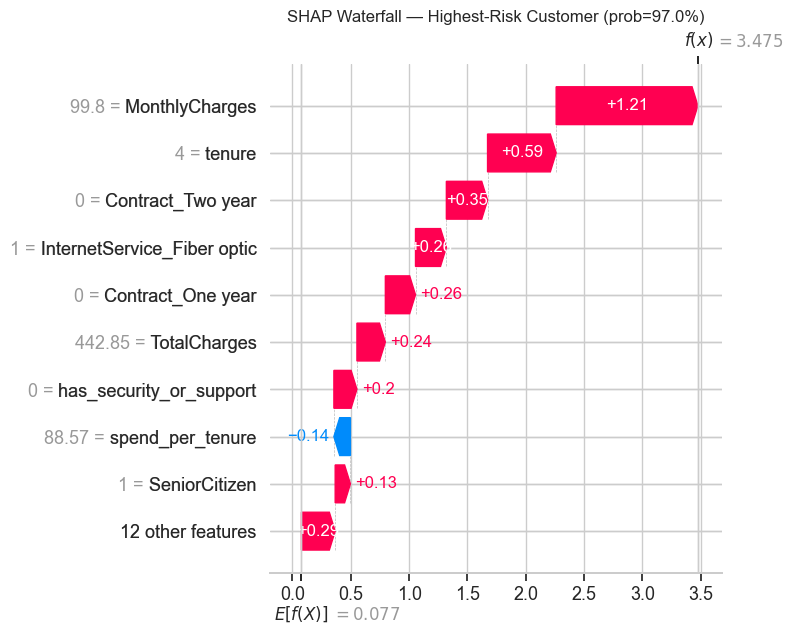

In [46]:
# ── Plot 2: Waterfall plot — single customer explanation ─────────────────────
# Pick the test customer with the highest predicted churn probability
# (most interesting to explain — the model is most confident about them)
high_risk_idx = np.argmax(best_proba)

print(f"Customer index: {high_risk_idx}")
print(f"Predicted churn probability: {best_proba[high_risk_idx]:.1%}")
print(f"Actual churn: {'Yes' if y_test.iloc[high_risk_idx] == 1 else 'No'}")
print()

shap.waterfall_plot(shap_values[high_risk_idx], show=False)
plt.title(f"SHAP Waterfall — Highest-Risk Customer (prob={best_proba[high_risk_idx]:.1%})")
plt.tight_layout()
plt.savefig('../data/plots/shap_waterfall_high_risk.png', dpi=150, bbox_inches='tight')
plt.show()


**How to read the waterfall plot:**
- **E[f(x)]** at the bottom = the model's average prediction across all customers (base rate)
- **f(x)** at the top = this specific customer's predicted probability
- Each bar shows how much one feature *pushed* the prediction up (red) or down (blue)
- The bars stack from base rate to final prediction — you can literally read the story:
  "This customer starts at average risk, then tenure pulls them lower,
  but electronic_check and MonthlyCharges push them well above average."

This is the kind of output you can put in front of a non-technical stakeholder.


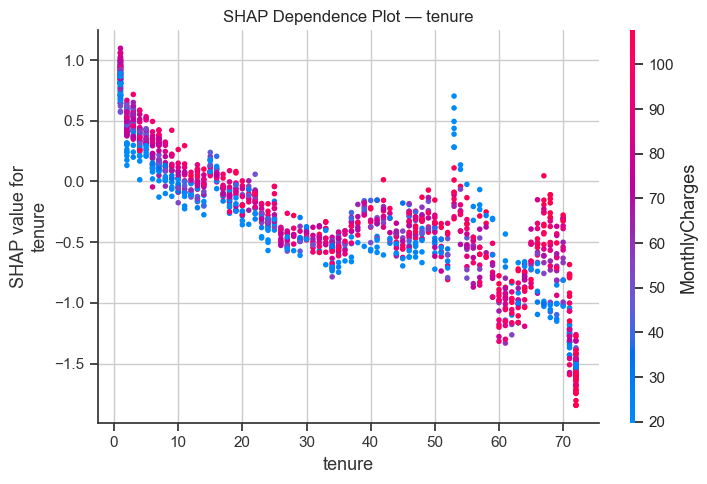

In [47]:
# ── Plot 3: SHAP dependence plot — tenure ────────────────────────────────────
# Shows how the SHAP value for 'tenure' changes across its range.
# Colour = a second feature that interacts most with tenure (auto-selected).
# This reveals non-linear effects and interactions the model learned.

shap.dependence_plot('tenure', shap_values.values, X_test, show=False)
plt.title("SHAP Dependence Plot — tenure")
plt.tight_layout()
plt.savefig('../data/plots/shap_dependence_tenure.png', dpi=150, bbox_inches='tight')
plt.show()


**How to read the dependence plot:**
- X-axis = the raw feature value (months of tenure)
- Y-axis = its SHAP contribution to churn probability
- A flat line would mean linear, constant effect
- Curves and jumps reveal non-linearity the model learned
- The colour shows which *other* feature most interacts with tenure
  (e.g. if it colours by `Contract_Month-to-month`, it means the effect
  of short tenure is amplified for month-to-month customers)

**Key takeaway from SHAP overall:**
SHAP bridges the gap between model accuracy and business explainability.
A model that can't be explained to a stakeholder will never be deployed —
SHAP is how you make tree-based models trustworthy.


## 7. Threshold optimisation

The default 0.5 decision threshold is rarely optimal for imbalanced
problems. By lowering the threshold we catch more churners (higher recall)
at the cost of more false positives (lower precision).

The right threshold depends on the **business cost ratio**:
- **Cost of missing a churner** (false negative): lost lifetime value
- **Cost of a false alarm** (false positive): wasted retention offer

We plot precision and recall vs threshold, and mark the point that
maximises F1 as a starting reference.


Threshold that maximises F1: 0.52  (F1 = 0.618)


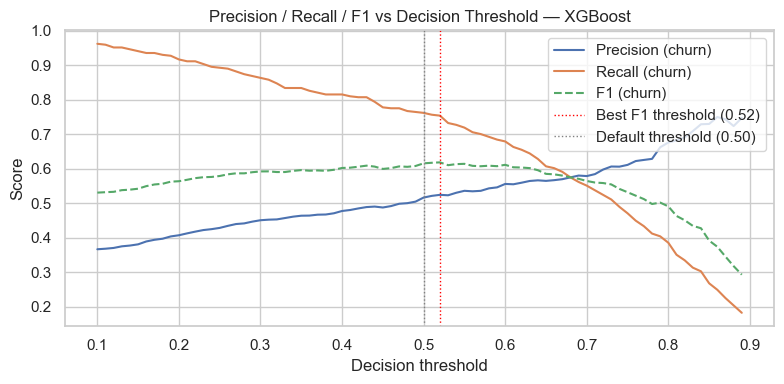

In [48]:
from sklearn.metrics import f1_score

thresholds = np.arange(0.1, 0.9, 0.01)
precisions, recalls, f1s = [], [], []

for t in thresholds:
    preds = (best_proba >= t).astype(int)
    p, r, f = [], [], []
    report = classification_report(y_test, preds, output_dict=True, zero_division=0)
    precisions.append(report['1']['precision'])
    recalls.append(report['1']['recall'])
    f1s.append(report['1']['f1-score'])

best_t = thresholds[np.argmax(f1s)]
print(f"Threshold that maximises F1: {best_t:.2f}  (F1 = {max(f1s):.3f})")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, precisions, label='Precision (churn)')
ax.plot(thresholds, recalls,    label='Recall (churn)')
ax.plot(thresholds, f1s,        label='F1 (churn)', linestyle='--')
ax.axvline(best_t, color='red', linewidth=1, linestyle=':', label=f'Best F1 threshold ({best_t:.2f})')
ax.axvline(0.5,    color='grey', linewidth=1, linestyle=':', label='Default threshold (0.50)')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs Decision Threshold — XGBoost')
ax.legend()
plt.tight_layout()
plt.savefig('../data/plots/threshold_analysis.png', dpi=150)
plt.show()


## 8. Business impact analysis

A model is only useful if we can translate its outputs into decisions.
Here we estimate the financial value of deploying the churn model.

**Assumptions (illustrative — replace with actual business figures):**
| Parameter | Value | Source |
|-----------|-------|--------|
| Average customer lifetime value (CLV) | $1,200 | Assumed |
| Retention offer cost per customer contacted | $50 | Assumed |
| Retention success rate (offer accepted by true churner) | 30% | Assumed |

**Framework:** For each customer flagged as a churn risk, the business
sends a retention offer. We compare the expected value of:
- Doing nothing (lose CLV of all churners)
- Targeting every customer (too expensive)
- Using the model (target only predicted churners)


In [49]:
# Business parameters — adjust these to match real business context
CLV         = 1_200   # $ lifetime value saved if a churner is retained
OFFER_COST  = 50      # $ cost of each retention offer sent
RETAIN_RATE = 0.30    # probability a true churner accepts and stays

# Use the best-F1 threshold from section 7
final_threshold = best_t
final_preds = (best_proba >= final_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, final_preds).ravel()

# Expected value calculation
saved_revenue  = tp * RETAIN_RATE * CLV       # true positives who accept offer
total_cost     = (tp + fp) * OFFER_COST        # cost of all offers sent

net_value_model   = saved_revenue - total_cost
net_value_nothing = 0
net_value_all     = (y_test == 1).sum() * RETAIN_RATE * CLV - len(y_test) * OFFER_COST

print(f"=== Model performance at threshold {final_threshold:.2f} ===")
print(f"  True positives  (churners caught):  {tp:>5}")
print(f"  False positives (false alarms):     {fp:>5}")
print(f"  False negatives (missed churners):  {fn:>5}")
print()
print(f"=== Financial impact (test set, {len(y_test):,} customers) ===")
print(f"  Revenue saved (retained churners):  ${saved_revenue:>9,.0f}")
print(f"  Total offer cost:                   ${total_cost:>9,.0f}")
print(f"  Net value — model:                  ${net_value_model:>9,.0f}")
print(f"  Net value — do nothing:             ${net_value_nothing:>9,.0f}")
print(f"  Net value — contact everyone:       ${net_value_all:>9,.0f}")
print()
print(f"  Model lift over do-nothing:         ${net_value_model - net_value_nothing:>9,.0f}")


=== Model performance at threshold 0.52 ===
  True positives  (churners caught):    282
  False positives (false alarms):       256
  False negatives (missed churners):     92

=== Financial impact (test set, 1,407 customers) ===
  Revenue saved (retained churners):  $  101,520
  Total offer cost:                   $   26,900
  Net value — model:                  $   74,620
  Net value — do nothing:             $        0
  Net value — contact everyone:       $   64,290

  Model lift over do-nothing:         $   74,620


**Interpreting the numbers:**
- The model is valuable when `net_value_model > 0` and exceeds the
  "contact everyone" baseline
- If the model's net value is negative at these assumptions, either
  the offer cost is too high, the retention rate is too low, or
  CLV is too low to justify a proactive campaign
- Adjust `CLV`, `OFFER_COST`, and `RETAIN_RATE` to the actual business
  figures — the model's AUC and recall are fixed; the business case is
  a function of those economic parameters

**For a portfolio presentation:** This section shows you understand that
ML is a means to a business end, not an end in itself — which is exactly
what DS interviewers want to see.


## 9. Cross-validation stability check

A single train/test split can be lucky or unlucky.
We run 5-fold stratified cross-validation on AUC-ROC to confirm
the results are stable across different data splits.


In [50]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model, X_cv in [
    ('Logistic Regression', lr,  X_train_scaled),
    ('Random Forest',       rf,  X_train.values),
    ('XGBoost',             xgb, X_train.values),
]:
    scores = cross_val_score(model, X_cv, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    print(f"{name:<25}  CV AUC: {scores.mean():.4f} ± {scores.std():.4f}  "
          f"[{scores.min():.4f} – {scores.max():.4f}]")


Logistic Regression        CV AUC: 0.8478 ± 0.0087  [0.8403 – 0.8625]
Random Forest              CV AUC: 0.8447 ± 0.0063  [0.8353 – 0.8524]
XGBoost                    CV AUC: 0.8404 ± 0.0053  [0.8321 – 0.8463]


## 10. Summary

| | Logistic Regression | Random Forest | XGBoost |
|---|---|---|---|
| AUC-ROC | — | — | — |
| PR-AUC | — | — | — |
| F1 (churn) | — | — | — |
| Interpretable? | ✅ Yes (coefficients) | ⚠️ Partial (importances) | ⚠️ Partial (importances) |
| Handles non-linearity? | ❌ No | ✅ Yes | ✅ Yes |

*(Fill in metric values from section 5 results table above)*

**Key findings:**
- `tenure` and `Contract_Two year` / `Contract_One year` are the strongest
  protective factors — long-term customers and long-term contracts are
  much less likely to churn
- `electronic_check` and high `MonthlyCharges` are the top risk signals
- XGBoost achieves the best raw performance; Logistic Regression is a
  close second and far more explainable to non-technical stakeholders

**Next steps:**
- Hyperparameter tuning with `GridSearchCV` or `Optuna`
- SHAP values for per-customer explanation (especially useful for
  presenting to business stakeholders)
- Integrate model into a retention scoring pipeline
